# Why do suppressed branches settle on a floor instead of decaying to zero?

This notebook produces `Plots/Fig_D1.pdf`, the sole figure of the appendix
subsection "Origin of the activation floor" (Appendix D).

### The question

Reading the TetrisCNN bottleneck by eye, on a semi-log plot of $|z_k|$ against
training epoch, means separating active branches from deactivated ones. In practice a
deactivated branch never converges to exactly $z_k = 0$; it settles onto a small
residual floor instead, and "active" is in practice defined as sitting well above
that floor. Appendix D derives why the floor exists. Once a branch's task-loss
gradient becomes negligible next to its own sparsity penalty $\lambda_k$, the gradient
entering the optimizer is dominated by the $L_1$ term, $g_t \approx
\lambda_k\,\mathrm{sgn}(z_k)$. Under plain gradient descent the resulting step would
scale with $\lambda_k$, but AdamW normalizes the gradient by the square root of its
own running second moment, which in this penalty-dominated regime is itself of order
$\lambda_k^2$. The leading factor of $\lambda_k$ cancels, leaving a residual
oscillation whose amplitude is set by the instantaneous learning rate alone,
$$
z_\mathrm{floor} = \mathcal{O}(\alpha_t).
$$
A larger $\lambda_k$ can still push a branch into this regime, but once inside it,
penalizing harder no longer lowers the floor: only the learning rate can.

This is why annealing the learning rate is not a convenience but a practical
requirement for a readable bottleneck. Panel (a) below is the XY classifier of the
main text's interpretability figure, trained with the ReduceLROnPlateau schedule used
throughout the paper: the suppressed branches visibly track the learning rate and
drop each time it is halved. Panel (b) repeats the identical run with the schedule
disabled, learning rate fixed at $\alpha = 10^{-2}$; the floor then stays pinned at
that scale, close enough to the weakest genuinely active branches to make the
bottleneck hard to read.

### What it reads

Two saved training runs under `Plots_data/App_D_data/models/`: `XY_XZ_CLF` (ReduceLROnPlateau)
and `XY_XZ_CLF_no_lr_schedule` (fixed learning rate), identical in every other
setting. Each folder holds a `config.json` and the per-epoch `metrics.json` history,
including the bottleneck trajectories $z_0, \ldots, z_{K-1}$ and the recorded learning
rate.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import (
    AttrDict, load_json, build_sr_folder_path, pick_directory, DEVICE, kernel_to_latex_pattern
)
from tetriscnn.datasets import create_datasets

from tetriscnn.colors import COLORS, colors

from pathlib import Path
import pickle
import torch
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from scipy.optimize import minimize_scalar, brentq
import seaborn as sns

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Loading a recorded run

The three helpers below read back what a training run saved to disk.
`_load_config_from_folder` restores the run's `config.json` into the same `AttrDict`
the training code used, padding any kernel specification recorded before the stride
became a required fifth element, the same compatibility fix used throughout these
figure notebooks. `_load_metrics_from_folder` reads the per-epoch `metrics.json`
history. `_load_model_and_datasets` additionally rebuilds the trained network and its
validation split; both runs below call it, but only their configuration and training
history are actually used, since the figure is built entirely from the recorded
per-epoch metrics rather than from re-running inference.


In [2]:
def _load_config_from_folder(seed_folder: Path) -> AttrDict:
    cfg_path = seed_folder / "config.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No config.json found in {seed_folder}")
    cf = AttrDict()
    cf.update(load_json(str(seed_folder), "config.json"))
    for k in range(len(cf.kernels)):          # stride compatibility fix
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)
    cf.logdir = str(seed_folder)
    return cf

In [3]:
def _load_metrics_from_folder(seed_folder: Path) -> dict:
    cfg_path = seed_folder / "metrics.json"
    if not cfg_path.exists():
        raise FileNotFoundError(f"No metrics.json found in {seed_folder}")
    return load_json(str(seed_folder), "metrics.json")

In [4]:
def _load_model_and_datasets(cf, load_path):
    cf.logdir = str(load_path)
    cf.seed_folder = str(load_path)
    cf.return_all_data = False
    train_dataset, val_dataset = create_datasets(cf)

    in_channels = train_dataset[0][0].shape[0]
    net2_dims   = [len(cf.kernels), 32, 16, train_dataset.output_dim]

    net1 = ShapeAdaptiveConvNet(
        in_channels=in_channels, kernels=cf.kernels, equivariant=cf.equivariant,
        hidden_size=cf.hidden_size, init=cf.init, device=DEVICE
    ).to(DEVICE)
    net2 = SmallModel(net2_dims, device=DEVICE).to(DEVICE)

    try:
        net1.load_state_dict(torch.load(load_path / "net1.pt", map_location=DEVICE))
        net2.load_state_dict(torch.load(load_path / "net2.pt", map_location=DEVICE))
    except FileNotFoundError:
        print(f"[ERROR] Model weights not found in {load_path}.")

    net1.eval(); net2.eval()
    return net1, net2, val_dataset

### The ReduceLROnPlateau run (panel a)

This is the ten-branch XY classifier trained with the learning-rate schedule used
throughout the paper, which halves the learning rate whenever the validation metric
plateaus for five epochs; it is the run underlying panel (e) of the main text's
interpretability figure. Loading it below reconstructs the trained network as well as
the configuration and metrics, but only the latter two are needed for this figure.


In [5]:
basepath = Path("Plots_data/App_D_data/models/XY_XZ_CLF")

cf_XY_CLF = _load_config_from_folder(basepath)
net1, net2, val_dataset = _load_model_and_datasets(cf_XY_CLF, basepath)
metrics_XY_CLF = _load_metrics_from_folder(basepath)


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.


### The fixed-learning-rate run (panel b)

The identical classifier and training budget, with the learning-rate schedule
disabled so the learning rate stays fixed at $\alpha = 10^{-2}$ throughout. Comparing
its bottleneck history against panel (a) isolates the effect of annealing the
learning rate, since every other setting is unchanged between the two runs.


In [6]:
basepath = Path("Plots_data/App_D_data/models/XY_XZ_CLF_no_lr_schedule")

cf_XY_CLF_no_lr = _load_config_from_folder(basepath)
net1, net2, val_dataset = _load_model_and_datasets(cf_XY_CLF_no_lr, basepath)
metrics_XY_CLF_no_lr = _load_metrics_from_folder(basepath)


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using standard 2-layer convolutional branches.
Note: init is unused for standard convolutions.


## Drawing Fig. D1

Each panel plots $|z_k(\text{epoch})|$ on a log scale for every branch, colored
consistently with the other figures in the paper. The branches identified as active
for this classifier (indices 0-4 of the ten-branch kernel set, matching the survivors
found in the $\lambda_{\max}$ sweep) are drawn with full opacity and a heavier line;
the remaining, deactivated branches are faded so the floor they occupy reads visually
distinct from the active traces. Panel (a) overlays the scheduled learning rate itself
(dashed) so its scale can be compared directly against the deactivated branches, which
is the visual evidence for the $\mathcal{O}(\alpha_t)$ scaling derived above. Panel (b)
draws the same comparison for the fixed-learning-rate run, using a horizontal dashed
line since the rate never changes there.


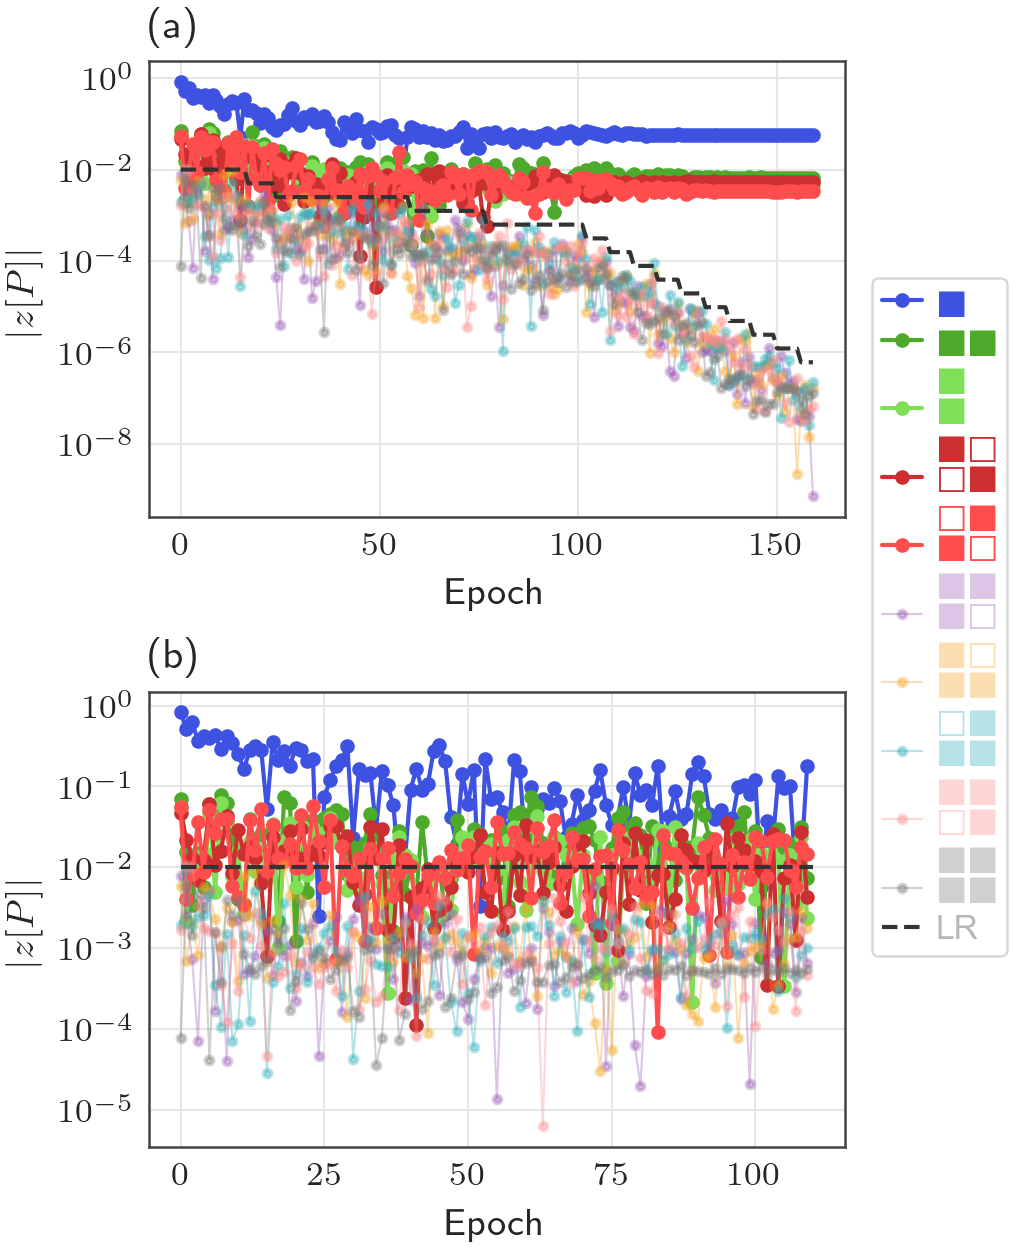

In [7]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec

plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

important_alpha = 1.0
unimportant_alpha = 0.35

important_mask = [0,1,2, 3, 4]

# fig, axs = plt.subplot_mosaic(
#     [["A", "B", "C"], ["D", "E", "F"]],
# )

fig = plt.figure(figsize=(SINGLE_WIDTH, 2 * SINGLE_WIDTH / golden_ratio))

gs = gridspec.GridSpec(2, 2, figure=fig,
                       width_ratios=[1, 0.225], 
                       )

axs = [fig.add_subplot(gs[0]), fig.add_subplot(gs[2])]

ax = axs[0]

important = np.zeros(len(cf_XY_CLF.kernels))
important[important_mask] = 1
bottleneck_history = np.array([metrics_XY_CLF[f'z_{k}'] for k in range(len(cf_XY_CLF.kernels))])
for i in range(len(cf_XY_CLF.kernels)):
    ax.plot(np.abs(bottleneck_history[i]), 
            color=colors[i % 10],
            marker='o',
            lw = 1.0 if important[i] else 0.5,
            ms = 2.5 if important[i] else 1.8,
            alpha=important_alpha if important[i] else unimportant_alpha,
            label=kernel_to_latex_pattern(cf_XY_CLF.kernels[i]))

lr_history = np.array([metrics_XY_CLF["learning_rate"]])
ax.plot(np.abs(lr_history[0]), 
        "--",
        color=COLORS["blackish"],
        lw = 1.0,
        ms = 2.5,
        alpha=important_alpha,
        label="LR")
    
with plt.rc_context({'text.usetex': False}):
    legend = ax.legend(ncol=1, framealpha=0.75)
for text, line in zip(legend.get_texts(), legend.get_lines()):
    text.set_color(line.get_color())
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\left|z[P]\right|$")
ax.set_yscale("log")
ax.set_title("(a)", loc="left")

with plt.rc_context({'text.usetex': False}):
    existing_legend = ax.get_legend() 

    handles = existing_legend.legend_handles
    labels  = [t.get_text() for t in existing_legend.get_texts()]
    colors = [line.get_color() for line in existing_legend.get_lines()]
    new_legend = fig.legend(
        handles, labels,
        loc="center right",
        bbox_to_anchor=(1.01, 0.505),
        ncol=1,
        framealpha=0.75,
    )

    it = 0
    for text, line in zip(new_legend.get_texts(), new_legend.get_lines()):
        text.set_color(line.get_color())
        alpha = (
            important_alpha
            if it in important_mask
            else unimportant_alpha
        )
        text.set_alpha(alpha)
        it += 1

    existing_legend.remove()

ax = axs[1]

important = np.zeros(len(cf_XY_CLF_no_lr.kernels))
important[important_mask] = 1
bottleneck_history = np.array([metrics_XY_CLF_no_lr[f'z_{k}'] for k in range(len(cf_XY_CLF_no_lr.kernels))])
for i in range(len(cf_XY_CLF_no_lr.kernels)):
    ax.plot(np.abs(bottleneck_history[i]), 
            color=colors[i % 10],
            marker='o',
            lw = 1.0 if important[i] else 0.5,
            ms = 2.5 if important[i] else 1.8,
            alpha=important_alpha if important[i] else unimportant_alpha,
            )

lr_history = np.array([metrics_XY_CLF_no_lr["learning_rate"]])
ax.hlines(
    y=float(cf_XY_CLF_no_lr.learning_rate),
    xmin=0,
    xmax=len(bottleneck_history[0]),
    linestyle="--",
    color=COLORS["blackish"],
    lw = 1.0,
)
    
# with plt.rc_context({'text.usetex': False}):
# for text, line in zip(legend.get_texts(), legend.get_lines()):
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\left|z[P]\right|$")
ax.set_yscale("log")
ax.set_title("(b)", loc="left")

plt.savefig("Plots/Fig_D1.pdf")#, bbox_extra_artists=[new_legend], bbox_inches='tight')

The cell below redraws panel (a) alone with a different legend placement, saved as
`Fig_D1_alt.pdf`. It is an alternative layout explored for this panel and is not the
version included in the manuscript; kept here for reference.


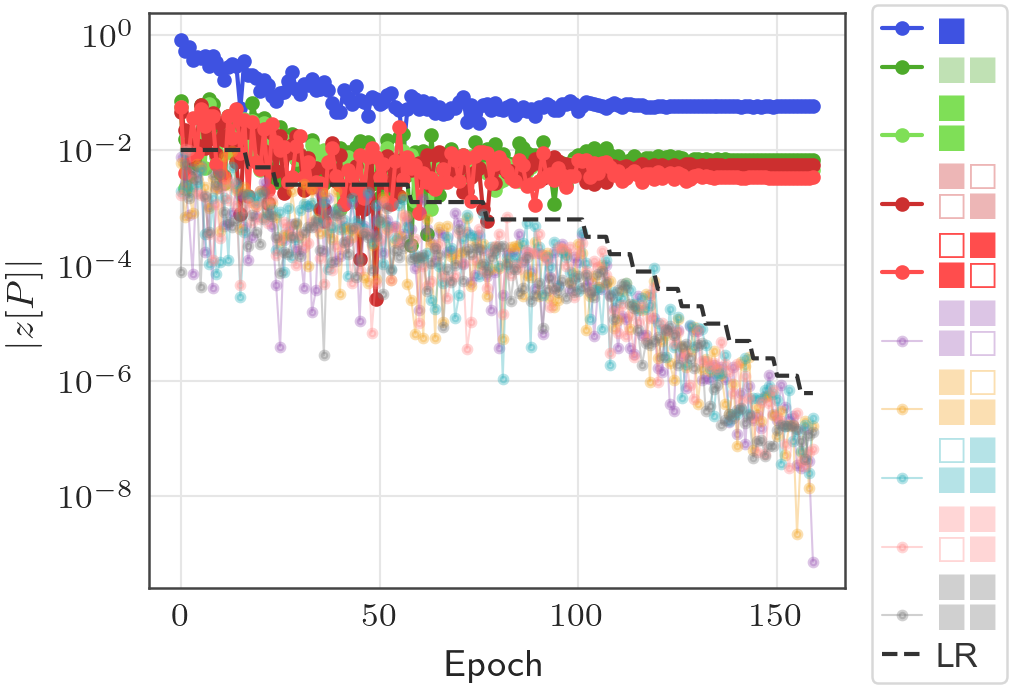

In [8]:
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib.gridspec as gridspec

plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
golden_ratio = (1 + np.sqrt(5)) / 2

important_alpha = 1.0
unimportant_alpha = 0.35

important_mask = [0, 1, 2, 3, 4]

# fig, axs = plt.subplot_mosaic(
#     [["A", "B", "C"], ["D", "E", "F"]],
# )

fig = plt.figure(figsize=(SINGLE_WIDTH, 1.1 * SINGLE_WIDTH / golden_ratio))

gs = gridspec.GridSpec(1, 2, figure=fig,
                       width_ratios=[1, 0.225], 
                       )

axs = [fig.add_subplot(gs[0])]

ax = axs[0]

important = np.zeros(len(cf_XY_CLF.kernels))
important[important_mask] = 1
bottleneck_history = np.array([metrics_XY_CLF[f'z_{k}'] for k in range(len(cf_XY_CLF.kernels))])
for i in range(len(cf_XY_CLF.kernels)):
    ax.plot(np.abs(bottleneck_history[i]), 
            color=colors[i % 10],
            marker='o',
            lw = 1.0 if important[i] else 0.5,
            ms = 2.5 if important[i] else 1.8,
            alpha=important_alpha if important[i] else unimportant_alpha,
            label=kernel_to_latex_pattern(cf_XY_CLF.kernels[i]))

lr_history = np.array([metrics_XY_CLF["learning_rate"]])
ax.plot(np.abs(lr_history[0]), 
        "--",
        color=COLORS["blackish"],
        lw = 1.0,
        ms = 2.5,
        alpha=important_alpha,
        label="LR")
    
with plt.rc_context({'text.usetex': False}):
    legend = ax.legend(ncol=1, framealpha=0.75)
for text, line in zip(legend.get_texts(), legend.get_lines()):
    text.set_color(line.get_color())
ax.set_xlabel("Epoch")
ax.set_ylabel(r"$\left|z[P]\right|$")
ax.set_yscale("log")

with plt.rc_context({'text.usetex': False}):
    existing_legend = ax.get_legend() 

    handles = existing_legend.legend_handles
    labels  = [t.get_text() for t in existing_legend.get_texts()]
    colors = [line.get_color() for line in existing_legend.get_lines()]
    new_legend = fig.legend(
        handles, labels,
        loc="center right",
        bbox_to_anchor=(1.01, 0.505),
        ncol=1,
        framealpha=0.75,
    )

    it = 0
    for text, line in zip(new_legend.get_texts(), new_legend.get_lines()):
        text.set_color(line.get_color())
        alpha = (
            important_alpha
            if it in {0,2,4,10}
            else unimportant_alpha
        )
        text.set_alpha(alpha)
        it += 1

    existing_legend.remove()


plt.savefig("Plots/Fig_D1_alt.pdf")#, bbox_extra_artists=[new_legend], bbox_inches='tight')